# DenseNet-121 Skin Lesion Classifier — HAM10000

**Dataset:** HAM10000 · 7 classes: MEL, NV, BCC, AKIEC, BKL, DF, VASC  
**Augmentation:** Real images + GAN-generated / Reinhard-normalised images  
**Architecture:** DenseNet-121 (ImageNet pre-trained, head replaced for 7-way classification)  
**Training:** Warm-up freeze (5 epochs) → full fine-tune, AdamW + CosineAnnealingLR, AMP mixed precision

---
## 1 · Imports & Config

In [1]:
# ── Standard library ───────────────────────────────────────────────────────
import os
import random
import time
import logging
from pathlib import Path

# ── Numerical / ML ──────────────────────────────────────────────────────────
import numpy as np
import torch
import torch.nn as nn
from torch.cuda.amp import GradScaler
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as T
from torchvision.models import densenet121, DenseNet121_Weights

# ── Data helpers ────────────────────────────────────────────────────────────
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    roc_curve,
    auc as sklearn_auc,
    confusion_matrix,
)
from sklearn.preprocessing import label_binarize

# ── Progress / Plotting ─────────────────────────────────────────────────────
from tqdm import tqdm
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# ═══════════════════════════════════════════════════════════════════════════════
#  HYPER-PARAMETERS  (edit here only)
# ═══════════════════════════════════════════════════════════════════════════════
IMG_SIZE      = 224
BATCH_SIZE    = 8
EPOCHS        = 30
LR            = 1e-4
SEED          = 42
WARMUP_EPOCHS = 5          # freeze backbone for first N epochs

device   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_CUDA = device.type == 'cuda'

CLASS_NAMES = ['MEL', 'NV', 'BCC', 'AKIEC', 'BKL', 'DF', 'VASC']
NUM_CLASSES  = len(CLASS_NAMES)

# ── Paths ───────────────────────────────────────────────────────────────────
ROOT      = Path().cwd()                             # notebook lives in skin cancer/
DATA_ROOT = ROOT / 'dataset' / 'processed_images'
CKPT_DIR  = ROOT / 'checkpoints'
CKPT_PATH = CKPT_DIR / 'densenet121_best.pt'
LOG_PATH  = ROOT.parent / 'results' / 'logs' / 'training.log'

CKPT_DIR.mkdir(parents=True, exist_ok=True)
LOG_PATH.parent.mkdir(parents=True, exist_ok=True)

print(f'Device    : {device}')
print(f'Data root : {DATA_ROOT.resolve()}')
print(f'Checkpoint: {CKPT_PATH.resolve()}')
print(f'Log file  : {LOG_PATH.resolve()}')

Device    : cuda
Data root : C:\Users\shara\Desktop\paper_learning\skin cancer\dataset\processed_images
Checkpoint: C:\Users\shara\Desktop\paper_learning\skin cancer\checkpoints\densenet121_best.pt
Log file  : C:\Users\shara\Desktop\paper_learning\results\logs\training.log


In [2]:
# ── Reproducibility ─────────────────────────────────────────────────────────
def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if USE_CUDA:
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark     = False

seed_everything(SEED)
print('Seeds fixed \u2713')

Seeds fixed ✓


In [3]:
# ── Logger setup ────────────────────────────────────────────────────────────
def get_logger(log_path: Path) -> logging.Logger:
    logger = logging.getLogger('DenseNet121')
    logger.setLevel(logging.INFO)
    logger.handlers.clear()  # avoid duplicate handlers on re-run

    fmt = logging.Formatter(
        '%(asctime)s | %(levelname)-8s | %(message)s',
        datefmt='%Y-%m-%d %H:%M:%S',
    )

    fh = logging.FileHandler(str(log_path), mode='a', encoding='utf-8')
    fh.setFormatter(fmt)
    logger.addHandler(fh)

    ch = logging.StreamHandler()
    ch.setFormatter(fmt)
    logger.addHandler(ch)

    return logger


logger = get_logger(LOG_PATH)
logger.info('=' * 70)
logger.info('DenseNet-121 HAM10000 Training Run')
logger.info(
    f'Device={device} | IMG_SIZE={IMG_SIZE} | BATCH_SIZE={BATCH_SIZE}'
    f' | EPOCHS={EPOCHS} | LR={LR} | SEED={SEED}'
)
logger.info('=' * 70)

2026-07-28 14:28:14 | INFO     | ======================================================================
2026-07-28 14:28:14 | INFO     | DenseNet-121 HAM10000 Training Run
2026-07-28 14:28:14 | INFO     | Device=cuda | IMG_SIZE=224 | BATCH_SIZE=8 | EPOCHS=30 | LR=0.0001 | SEED=42
2026-07-28 14:28:14 | INFO     | ======================================================================


---
## 2 · Dataset

In [4]:
# ── Transforms ──────────────────────────────────────────────────────────────
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

In [5]:
# ── Dataset class ────────────────────────────────────────────────────────────
class SkinLesionDataset(Dataset):
    """Flat (filepath, label) dataset built from real/ and normalized/ sub-dirs."""

    def __init__(self, samples, transform=None):
        self.samples   = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label


def build_sample_list(data_root: Path, class_names: list) -> list:
    """
    Scan processed_images/{cls}/real/ and normalized/ for every class.
    normalized/ is silently skipped if it does not exist (e.g. NV).
    """
    all_samples = []
    for cls_idx, cls_name in enumerate(class_names):
        cls_dir  = data_root / cls_name
        sub_dirs = [cls_dir / 'real']
        norm_dir = cls_dir / 'normalized'
        if norm_dir.exists():
            sub_dirs.append(norm_dir)
        else:
            print(f'  [INFO] {cls_name}/normalized/ not found - skipped (expected for NV)')

        for sub_dir in sub_dirs:
            if not sub_dir.exists():
                print(f'  [WARN] {sub_dir} does not exist - skipped')
                continue
            imgs = (
                list(sub_dir.glob('*.jpg'))
                + list(sub_dir.glob('*.jpeg'))
                + list(sub_dir.glob('*.png'))
            )
            all_samples.extend([(p, cls_idx) for p in imgs])

    return all_samples


# Build master list
all_samples = build_sample_list(DATA_ROOT, CLASS_NAMES)
all_labels  = [s[1] for s in all_samples]

print(f'\nTotal images found: {len(all_samples)}')
for i, cls in enumerate(CLASS_NAMES):
    cnt = sum(1 for lbl in all_labels if lbl == i)
    print(f'  {cls:>6}: {cnt}')

  [INFO] NV/normalized/ not found - skipped (expected for NV)

Total images found: 46935
     MEL: 6705
      NV: 6705
     BCC: 6705
   AKIEC: 6705
     BKL: 6705
      DF: 6705
    VASC: 6705


In [6]:
# ── Stratified 80 / 10 / 10 split ───────────────────────────────────────────
train_val_samples, test_samples, train_val_labels, test_labels = train_test_split(
    all_samples, all_labels,
    test_size=0.10, random_state=SEED, stratify=all_labels,
)

train_samples, val_samples, train_labels, val_labels = train_test_split(
    train_val_samples, train_val_labels,
    test_size=0.111,   # 0.111 × 0.90 ≈ 0.10 of total
    random_state=SEED, stratify=train_val_labels,
)


def print_split_counts(split_name, labels):
    print(f'\n{split_name} split ({len(labels)} total):')
    for i, cls in enumerate(CLASS_NAMES):
        cnt = labels.count(i)
        print(f'  {cls:>6}: {cnt}')


print_split_counts('Train', train_labels)
print_split_counts('Val',   val_labels)
print_split_counts('Test',  test_labels)

logger.info(
    f'Split sizes -> Train: {len(train_samples)}'
    f' | Val: {len(val_samples)} | Test: {len(test_samples)}'
)

2026-07-28 14:28:18 | INFO     | Split sizes -> Train: 37552 | Val: 4689 | Test: 4694



Train split (37552 total):
     MEL: 5365
      NV: 5365
     BCC: 5364
   AKIEC: 5365
     BKL: 5364
      DF: 5365
    VASC: 5364

Val split (4689 total):
     MEL: 670
      NV: 670
     BCC: 670
   AKIEC: 669
     BKL: 670
      DF: 670
    VASC: 670

Test split (4694 total):
     MEL: 670
      NV: 670
     BCC: 671
   AKIEC: 671
     BKL: 671
      DF: 670
    VASC: 671


In [7]:
# ── WeightedRandomSampler ────────────────────────────────────────────────────
class_counts   = np.bincount(train_labels, minlength=NUM_CLASSES).astype(float)
class_weights  = 1.0 / np.where(class_counts == 0, 1.0, class_counts)
sample_weights = np.array([class_weights[lbl] for lbl in train_labels])

sampler = WeightedRandomSampler(
    weights     = torch.DoubleTensor(sample_weights),
    num_samples = len(train_samples),
    replacement = True,
)

# ── Datasets ────────────────────────────────────────────────────────────────
train_ds = SkinLesionDataset(train_samples, transform=train_transform)
val_ds   = SkinLesionDataset(val_samples,   transform=eval_transform)
test_ds  = SkinLesionDataset(test_samples,  transform=eval_transform)

# ── DataLoaders ─────────────────────────────────────────────────────────────
loader_kwargs = dict(pin_memory=True, num_workers=0) if USE_CUDA else {}

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                          sampler=sampler, **loader_kwargs)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE,
                          shuffle=False, **loader_kwargs)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE,
                          shuffle=False, **loader_kwargs)

print(f'Train batches: {len(train_loader)} | '
      f'Val batches: {len(val_loader)} | '
      f'Test batches: {len(test_loader)}')

Train batches: 4694 | Val batches: 587 | Test batches: 587


---
## 3 · Model

In [8]:
# ── Build DenseNet-121 ───────────────────────────────────────────────────────
def build_model(num_classes: int) -> nn.Module:
    model = densenet121(weights=DenseNet121_Weights.DEFAULT)
    # DenseNet-121 final feature dim is 1024
    in_features = model.classifier.in_features  # 1024
    model.classifier = nn.Linear(in_features, num_classes)
    return model


model = build_model(NUM_CLASSES).to(device)
logger.info(
    f'Model: DenseNet-121 | classifier in_features='
    f'{model.classifier.in_features} -> out_features={NUM_CLASSES}'
)


# ── Freeze helpers ───────────────────────────────────────────────────────────
def freeze_backbone(model: nn.Module) -> None:
    """Freeze all layers except the classifier head."""
    for name, param in model.named_parameters():
        param.requires_grad = name.startswith('classifier')
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'  Backbone FROZEN   | trainable params: {trainable:,}')


def unfreeze_all(model: nn.Module) -> None:
    """Unfreeze every layer."""
    for param in model.parameters():
        param.requires_grad = True
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'  Backbone UNFROZEN | trainable params: {trainable:,}')


# ── Loss / Optimizer / Scheduler ────────────────────────────────────────────
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR, weight_decay=1e-4,
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
scaler    = GradScaler(enabled=USE_CUDA)

# Start with backbone frozen (warm-up phase)
freeze_backbone(model)
print('\nModel built and ready \u2713')

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to C:\Users\shara/.cache\torch\hub\checkpoints\densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 41.0MB/s]
2026-07-28 14:29:02 | INFO     | Model: DenseNet-121 | classifier in_features=1024 -> out_features=7


  Backbone FROZEN   | trainable params: 7,175

Model built and ready ✓


C:\Users\shara\AppData\Local\Temp\ipykernel_23080\4249679927.py:41: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = GradScaler(enabled=USE_CUDA)


---
## 4 · Training Loop

In [9]:
def run_epoch(loader, model, criterion, optimizer=None, scaler=None,
              phase='train', epoch=1, n_epochs=1):
    is_train = (phase == 'train')
    model.train() if is_train else model.eval()

    total_loss, correct, total = 0.0, 0, 0
    running_loss = 0.0

    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        pbar = tqdm(
            loader,
            desc=f"[DenseNet121] Epoch {epoch}/{n_epochs} | {phase}",
            leave=True
        )
        for imgs, labels in pbar:
            imgs, labels = imgs.to(device), labels.to(device)
            amp_enabled = USE_CUDA and is_train
            with torch.amp.autocast(device_type=device.type, enabled=amp_enabled):
                logits = model(imgs)
            loss = criterion(logits.float(), labels)

            if is_train:
                optimizer.zero_grad()
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

            running_loss += loss.item()
            total_loss   += loss.item() * imgs.size(0)
            preds         = logits.argmax(dim=1)
            correct      += (preds == labels).sum().item()
            total        += imgs.size(0)

            pbar.set_postfix(
                Loss=f"{running_loss / (pbar.n + 1):.4f}",
                Acc =f"{correct / total * 100:.2f}%"
            )

    return total_loss / total, correct / total



# ── Training loop ────────────────────────────────────────────────────────────
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0


for epoch in range(1, EPOCHS + 1):
    epoch_start = time.time()

    # Warm-up: unfreeze backbone after WARMUP_EPOCHS
    if epoch == WARMUP_EPOCHS + 1:
        logger.info(f'Epoch {epoch}: Unfreezing backbone for fine-tuning')
        unfreeze_all(model)
        # Re-create optimizer to include all parameters at a reduced LR
        optimizer = torch.optim.AdamW(
            model.parameters(), lr=LR * 0.1, weight_decay=1e-4
        )
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=EPOCHS - WARMUP_EPOCHS
        )

    train_loss, train_acc = run_epoch(
        train_loader, model, criterion,
        optimizer=optimizer, scaler=scaler, phase='train',
        epoch=epoch, n_epochs=EPOCHS,
    )
    val_loss, val_acc = run_epoch(
        val_loader, model, criterion, phase='val',
        epoch=epoch, n_epochs=EPOCHS,
    )
    scheduler.step()

    epoch_time = time.time() - epoch_start

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    log_msg = (
        f'Epoch [{epoch:02d}/{EPOCHS}]'
        f' | Time: {epoch_time:.1f}s'
        f' | Train Loss: {train_loss:.4f}  Train Acc: {train_acc*100:.2f}%'
        f' | Val Loss: {val_loss:.4f}  Val Acc: {val_acc*100:.2f}%'
    )
    logger.info(log_msg)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch':             epoch,
            'model_state_dict': model.state_dict(),
            'val_acc':           val_acc,
            'val_loss':          val_loss,
        }, CKPT_PATH)
        logger.info(f'  \u2713 Checkpoint saved (val_acc={val_acc*100:.2f}%)')

logger.info(f'Training complete. Best val accuracy: {best_val_acc*100:.2f}%')
print(f'\nTraining done! Best val accuracy: {best_val_acc*100:.2f}%')

[DenseNet121] Epoch 1/30 | train: 100%|██████████| 4694/4694 [05:49<00:00, 13.43it/s, Acc=57.79%, Loss=1.2555]
[DenseNet121] Epoch 1/30 | val: 100%|██████████| 587/587 [00:41<00:00, 14.11it/s, Acc=65.30%, Loss=1.0009]
2026-07-28 14:35:36 | INFO     | Epoch [01/30] | Time: 391.3s | Train Loss: 1.2555  Train Acc: 57.79% | Val Loss: 0.9994  Val Acc: 65.30%
2026-07-28 14:35:37 | INFO     |   ✓ Checkpoint saved (val_acc=65.30%)
[DenseNet121] Epoch 2/30 | train: 100%|██████████| 4694/4694 [06:48<00:00, 11.49it/s, Acc=67.72%, Loss=0.9454]
[DenseNet121] Epoch 2/30 | val: 100%|██████████| 587/587 [00:33<00:00, 17.74it/s, Acc=70.61%, Loss=0.8518]
2026-07-28 14:42:58 | INFO     | Epoch [02/30] | Time: 441.6s | Train Loss: 0.9454  Train Acc: 67.72% | Val Loss: 0.8525  Val Acc: 70.61%
2026-07-28 14:42:58 | INFO     |   ✓ Checkpoint saved (val_acc=70.61%)
[DenseNet121] Epoch 3/30 | train: 100%|██████████| 4694/4694 [05:48<00:00, 13.45it/s, Acc=70.84%, Loss=0.8584]
[DenseNet121] Epoch 3/30 | val: 100

  Backbone UNFROZEN | trainable params: 6,961,031


[DenseNet121] Epoch 6/30 | train: 100%|██████████| 4694/4694 [11:51<00:00,  6.60it/s, Acc=87.11%, Loss=0.3922]
[DenseNet121] Epoch 6/30 | val: 100%|██████████| 587/587 [00:33<00:00, 17.27it/s, Acc=94.58%, Loss=0.1545]
2026-07-28 15:14:23 | INFO     | Epoch [06/30] | Time: 745.3s | Train Loss: 0.3922  Train Acc: 87.11% | Val Loss: 0.1548  Val Acc: 94.58%
2026-07-28 15:14:23 | INFO     |   ✓ Checkpoint saved (val_acc=94.58%)
[DenseNet121] Epoch 7/30 | train: 100%|██████████| 4694/4694 [11:51<00:00,  6.60it/s, Acc=93.09%, Loss=0.2094]
[DenseNet121] Epoch 7/30 | val: 100%|██████████| 587/587 [00:34<00:00, 17.05it/s, Acc=95.09%, Loss=0.1338]
2026-07-28 15:26:49 | INFO     | Epoch [07/30] | Time: 745.5s | Train Loss: 0.2094  Train Acc: 93.09% | Val Loss: 0.1340  Val Acc: 95.09%
2026-07-28 15:26:49 | INFO     |   ✓ Checkpoint saved (val_acc=95.09%)
[DenseNet121] Epoch 8/30 | train: 100%|██████████| 4694/4694 [11:49<00:00,  6.62it/s, Acc=94.49%, Loss=0.1645]
[DenseNet121] Epoch 8/30 | val: 100

KeyboardInterrupt: 

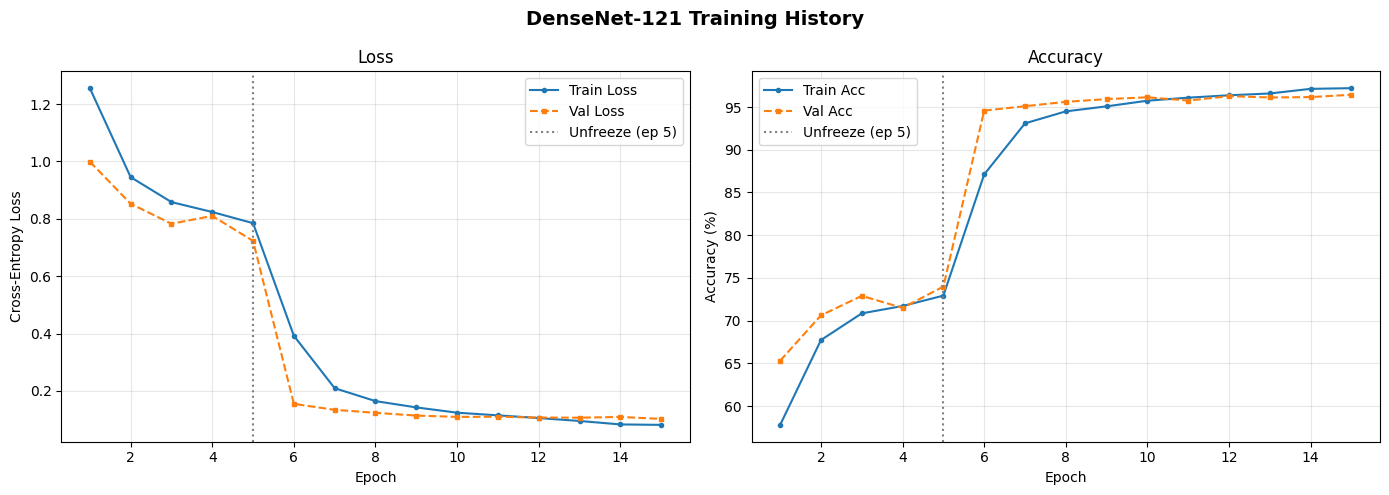

Saved -> densenet121_training_curves.png


In [13]:
# ── Training curves ──────────────────────────────────────────────────────────
epochs_range = range(1, 15 + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('DenseNet-121 Training History', fontsize=14, fontweight='bold')

ax1.plot(epochs_range, history['train_loss'], label='Train Loss', marker='o', ms=3)
ax1.plot(epochs_range, history['val_loss'],   label='Val Loss',   marker='s', ms=3, linestyle='--')
ax1.axvline(WARMUP_EPOCHS, color='grey', linestyle=':', label=f'Unfreeze (ep {WARMUP_EPOCHS})')
ax1.set_title('Loss'); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Cross-Entropy Loss')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(epochs_range, [a * 100 for a in history['train_acc']], label='Train Acc', marker='o', ms=3)
ax2.plot(epochs_range, [a * 100 for a in history['val_acc']],   label='Val Acc',   marker='s', ms=3, linestyle='--')
ax2.axvline(WARMUP_EPOCHS, color='grey', linestyle=':', label=f'Unfreeze (ep {WARMUP_EPOCHS})')
ax2.set_title('Accuracy'); ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('densenet121_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> densenet121_training_curves.png')

---
## 5 · Evaluation on Test Set

In [14]:
# ── Load best checkpoint ────────────────────────────────────────────────────
checkpoint = torch.load(CKPT_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(
    f"Loaded checkpoint from epoch {checkpoint['epoch']} "
    f"(val_acc={checkpoint['val_acc']*100:.2f}%)"
)
logger.info(
    f"Loaded best checkpoint: epoch={checkpoint['epoch']}, "
    f"val_acc={checkpoint['val_acc']*100:.2f}%"
)

2026-07-28 17:01:27 | INFO     | Loaded best checkpoint: epoch=15, val_acc=96.44%


Loaded checkpoint from epoch 15 (val_acc=96.44%)


In [15]:
# ── Inference on test set ───────────────────────────────────────────────────
all_preds = []
all_trues = []
all_probs = []

with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc='Testing'):
        imgs = imgs.to(device)
        with torch.amp.autocast(device_type=device.type, enabled=USE_CUDA):
            logits = model(imgs)
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        preds = probs.argmax(axis=1)
        all_probs.extend(probs)
        all_preds.extend(preds)
        all_trues.extend(labels.numpy())

all_probs = np.array(all_probs)   # (N, 7)
all_preds = np.array(all_preds)
all_trues = np.array(all_trues)

overall_acc = (all_preds == all_trues).mean()
print(f'\nOverall Test Accuracy: {overall_acc*100:.2f}%')
logger.info(f'Test Accuracy: {overall_acc*100:.2f}%')

Testing: 100%|██████████| 587/587 [00:28<00:00, 20.59it/s]
2026-07-28 17:01:59 | INFO     | Test Accuracy: 96.42%



Overall Test Accuracy: 96.42%


In [16]:
# ── Classification report ───────────────────────────────────────────────────
report = classification_report(
    all_trues, all_preds,
    target_names=CLASS_NAMES,
    digits=4,
)
print(report)
logger.info(f'Classification Report:\n{report}')

2026-07-28 17:02:22 | INFO     | Classification Report:
              precision    recall  f1-score   support

         MEL     0.9365    0.9239    0.9301       670
          NV     0.8838    0.9761    0.9277       670
         BCC     0.9865    0.9806    0.9836       671
       AKIEC     0.9777    0.9806    0.9792       671
         BKL     0.9821    0.9001    0.9393       671
          DF     0.9940    0.9955    0.9948       670
        VASC     0.9985    0.9925    0.9955       671

    accuracy                         0.9642      4694
   macro avg     0.9656    0.9642    0.9643      4694
weighted avg     0.9656    0.9642    0.9643      4694



              precision    recall  f1-score   support

         MEL     0.9365    0.9239    0.9301       670
          NV     0.8838    0.9761    0.9277       670
         BCC     0.9865    0.9806    0.9836       671
       AKIEC     0.9777    0.9806    0.9792       671
         BKL     0.9821    0.9001    0.9393       671
          DF     0.9940    0.9955    0.9948       670
        VASC     0.9985    0.9925    0.9955       671

    accuracy                         0.9642      4694
   macro avg     0.9656    0.9642    0.9643      4694
weighted avg     0.9656    0.9642    0.9643      4694



In [17]:
# ── Per-class & macro AUC-ROC ───────────────────────────────────────────────
y_bin = label_binarize(all_trues, classes=list(range(NUM_CLASSES)))  # (N, 7)

per_class_auc = roc_auc_score(y_bin, all_probs, average=None,       multi_class='ovr')
macro_auc     = roc_auc_score(y_bin, all_probs, average='macro',    multi_class='ovr')
weighted_auc  = roc_auc_score(y_bin, all_probs, average='weighted', multi_class='ovr')

print('Per-class AUC-ROC:')
for cls, auc_val in zip(CLASS_NAMES, per_class_auc):
    print(f'  {cls:>6}: {auc_val:.4f}')
print(f'  Macro    AUC: {macro_auc:.4f}')
print(f'  Weighted AUC: {weighted_auc:.4f}')
logger.info(f'Macro AUC-ROC: {macro_auc:.4f} | Weighted AUC-ROC: {weighted_auc:.4f}')

2026-07-28 17:02:24 | INFO     | Macro AUC-ROC: 0.9986 | Weighted AUC-ROC: 0.9986


Per-class AUC-ROC:
     MEL: 0.9973
      NV: 0.9969
     BCC: 0.9997
   AKIEC: 0.9995
     BKL: 0.9969
      DF: 1.0000
    VASC: 1.0000
  Macro    AUC: 0.9986
  Weighted AUC: 0.9986


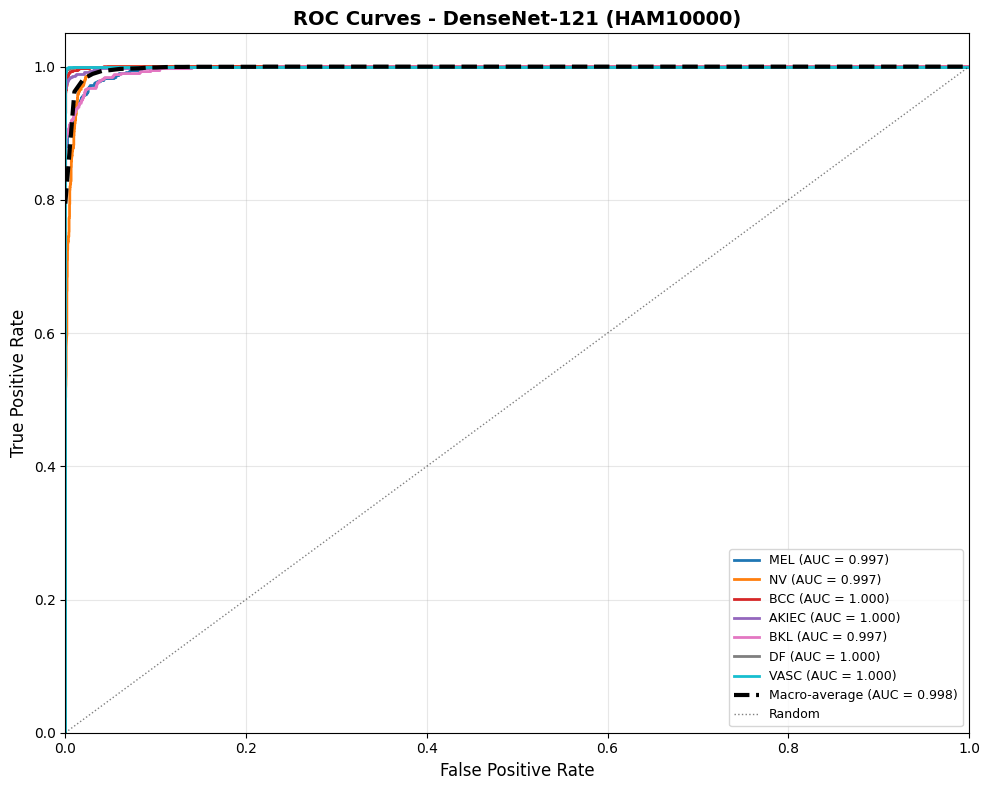

Saved -> densenet121_roc_curves.png


In [18]:
# ── ROC Curves — all 7 classes + macro-average on same axes ─────────────────
colors = plt.cm.tab10(np.linspace(0, 0.9, NUM_CLASSES))

fig, ax = plt.subplots(figsize=(10, 8))

mean_fpr         = np.linspace(0, 1, 100)
macro_tpr_interp = np.zeros(100)

for i, (cls_name, color) in enumerate(zip(CLASS_NAMES, colors)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc_val  = sklearn_auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'{cls_name} (AUC = {roc_auc_val:.3f})')
    macro_tpr_interp += np.interp(mean_fpr, fpr, tpr)

macro_tpr_interp /= NUM_CLASSES
macro_auc_plot    = sklearn_auc(mean_fpr, macro_tpr_interp)
ax.plot(mean_fpr, macro_tpr_interp,
        color='black', lw=3, linestyle='--',
        label=f'Macro-average (AUC = {macro_auc_plot:.3f})')
ax.plot([0, 1], [0, 1], 'k:', lw=1, alpha=0.5, label='Random')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves - DenseNet-121 (HAM10000)', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('densenet121_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> densenet121_roc_curves.png')

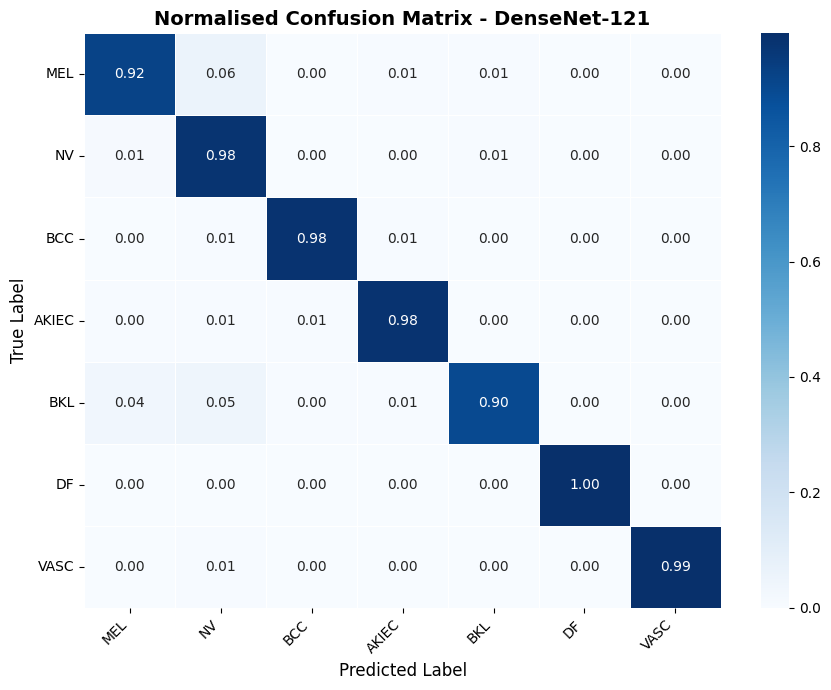

Saved -> densenet121_confusion_matrix.png


In [19]:
# ── Normalised Confusion Matrix ───────────────────────────────────────────────
cm      = confusion_matrix(all_trues, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    cm_norm,
    annot=True, fmt='.2f', cmap='Blues',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    linewidths=0.5, ax=ax
)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Normalised Confusion Matrix - DenseNet-121',
             fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig('densenet121_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> densenet121_confusion_matrix.png')